Single-task: AUC=0.9966, False Negative Rate=0.0368 (11 FN / 299 actual lenses)
Multi-head: AUC=0.9993, False Negative Rate=0.0134 (4 FN / 299 actual lenses)
Curriculum: AUC=0.9996, False Negative Rate=0.0334 (10 FN / 299 actual lenses)


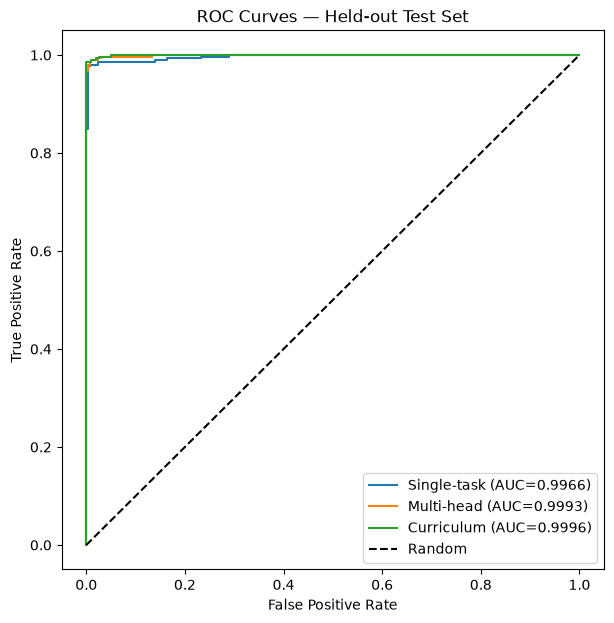

In [3]:
import sys
sys.path.append('src')
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with h5py.File('../data/processed/injected_v1/injected_dataset.h5', 'r') as f:
    images = f['images'][:]
metadata = pd.read_parquet('../data/processed/injected_v1/injected_dataset_metadata.parquet')
labels = metadata['label'].values

indices = np.arange(len(images))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=42)

class SimpleDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return torch.from_numpy(self.images[idx]).float().unsqueeze(0), torch.tensor(self.labels[idx], dtype=torch.long)

test_dataset = SimpleDataset(images[test_idx], labels[test_idx])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


class LensClassifier(nn.Module):
    def __init__(self, encoder, feature_dim=640):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, 2)
    def forward(self, x):
        return self.classifier(self.encoder(x))

class MultiHeadLensModel(nn.Module):
    def __init__(self, encoder, feature_dim=640):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, 2)
        self.ring_head = nn.Linear(feature_dim, 1)
        self.asymmetry_head = nn.Linear(feature_dim, 1)
        self.colour_head = nn.Linear(feature_dim, 1)
        self.elongation_head = nn.Linear(feature_dim, 1)
    def forward(self, x):
        f = self.encoder(x)
        return {'class_logits': self.classifier(f)}


def get_test_probs(model, is_multihead=False):
    model.eval()
    probs, true_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            logits = out['class_logits'] if is_multihead else out
            p = torch.softmax(logits, dim=1)[:, 1]
            probs.extend(p.cpu().numpy())
            true_labels.extend(lbls.numpy())
    return np.array(probs), np.array(true_labels)


def make_encoder():
    return timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=False, in_chans=1, num_classes=0)

single_task = LensClassifier(make_encoder()).to(device)
single_task.load_state_dict(torch.load('../models/zoobot_convnext_nano_best.pt'))

multihead = MultiHeadLensModel(make_encoder()).to(device)
multihead.load_state_dict(torch.load('../models/multihead_convnext_nano_best.pt'))

curriculum = LensClassifier(make_encoder()).to(device)
curriculum.load_state_dict(torch.load('../models/curriculum_convnext_nano_best.pt'))

results = {}
for name, model, is_mh in [('Single-task', single_task, False), ('Multi-head', multihead, True), ('Curriculum', curriculum, False)]:
    probs, true = get_test_probs(model, is_multihead=is_mh)
    auc = roc_auc_score(true, probs)
    preds = (probs > 0.5).astype(int)
    fn = np.sum((preds == 0) & (true == 1))
    tp = np.sum((preds == 1) & (true == 1))
    fnr = fn / (fn + tp)
    results[name] = {'auc': auc, 'fnr': fnr, 'probs': probs, 'true': true}
    print(f"{name}: AUC={auc:.4f}, False Negative Rate={fnr:.4f} ({fn} FN / {fn+tp} actual lenses)")

plt.figure(figsize=(7,7))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['true'], r['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.4f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Held-out Test Set')
plt.legend()
plt.savefig('../docs/roc_curves.png', dpi=150)
plt.show()